In [1]:
# ============================================================
# SÉRIE TEMPORAL DOS INDICADORES
# ============================================================

import rioxarray
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime

# Configurações de exibição
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:.3f}'.format)

# Configurações do matplotlib
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 10

# Caminhos
BASE = Path(r"C:\Users\bbert_xwhb76k\analises-GIS\01-monitoramento-vegetacao")
IND_DIR = BASE / "data" / "processed" / "indices"
RESULTS_DIR = BASE / "results"
RESULTS_DIR.mkdir(exist_ok=True)

print(f"BASE:        {BASE}")
print(f"ÍNDICES:     {IND_DIR}")
print(f"RESULTADOS:  {RESULTS_DIR}")
print(f"\n✓ Ambiente configurado")

BASE:        C:\Users\bbert_xwhb76k\analises-GIS\01-monitoramento-vegetacao
ÍNDICES:     C:\Users\bbert_xwhb76k\analises-GIS\01-monitoramento-vegetacao\data\processed\indices
RESULTADOS:  C:\Users\bbert_xwhb76k\analises-GIS\01-monitoramento-vegetacao\results

✓ Ambiente configurado


In [2]:
# ============================================================
# 1 — SÉRIE INTRA-ANUAL COMPLETA (2020-2025)
#      NDVI, EVI e NDMI
# ============================================================

import re

def extrair_serie_intraanual(indice):
    """Extrai série intra-anual de um índice (NDVI, EVI, NDMI)."""
    
    pasta = IND_DIR / indice
    arquivos = sorted(f for f in pasta.glob(f"{indice}_*.tif")
                     if "mediana" not in f.name)
    
    resultados = []
    
    for arq in arquivos:
        # Extrair data do nome
        match = re.search(r'(\d{8})', arq.stem)
        if not match:
            continue
        
        data_str = match.group(1)
        data = pd.to_datetime(data_str, format="%Y%m%d")
        
        # Carregar raster
        raster = rioxarray.open_rasterio(arq).squeeze()
        vals = raster.values[~np.isnan(raster.values)]
        
        if len(vals) == 0:
            continue
        
        resultados.append({
            "data": data,
            "data_str": data_str,
            "ano": data.year,
            "mes": data.month,
            "dia": data.day,
            "indice": indice.upper(),
            "media": vals.mean(),
            "mediana": np.median(vals),
            "std": vals.std(),
            "p25": np.percentile(vals, 25),
            "p75": np.percentile(vals, 75),
            "min": vals.min(),
            "max": vals.max(),
            "n_pixels": len(vals)
        })
    
    return pd.DataFrame(resultados)


# Processar os três índices
print("=" * 80)
print("EXTRAINDO SÉRIES INTRA-ANUAIS")
print("=" * 80)

dfs = []
for indice in ["ndvi", "evi", "ndmi"]:
    print(f"\nProcessando {indice.upper()}...")
    df = extrair_serie_intraanual(indice)
    dfs.append(df)
    print(f"   ✓ {len(df)} datas extraídas")

df_intraanual = pd.concat(dfs, ignore_index=True)
df_intraanual = df_intraanual.sort_values(["indice", "data"]).reset_index(drop=True)

print(f"\n✓ Total de registros: {len(df_intraanual)}")

# Salvar
output = RESULTS_DIR / "serie_intraanual_completa.csv"
df_intraanual.to_csv(output, index=False)
print(f"✅ Salvo: {output}")

EXTRAINDO SÉRIES INTRA-ANUAIS

Processando NDVI...
   ✓ 69 datas extraídas

Processando EVI...
   ✓ 69 datas extraídas

Processando NDMI...
   ✓ 69 datas extraídas

✓ Total de registros: 207
✅ Salvo: C:\Users\bbert_xwhb76k\analises-GIS\01-monitoramento-vegetacao\results\serie_intraanual_completa.csv


In [3]:
# ============================================================
#  2- SÉRIE ANUAL COMPLETA — 2020-2025
# ============================================================

df_anual_completa = df_intraanual.groupby(["indice", "ano"]).agg(
    media=("media", "mean"),
    mediana=("mediana", "median"),
    std=("std", "mean"),
    min=("min", "min"),
    max=("max", "max"),
    n_datas=("data", "count")
).reset_index()

print("=" * 100)
print("SÉRIE ANUAL COMPLETA — 2020 a 2025")
print("=" * 100)

for indice in ["NDVI", "EVI", "NDMI"]:
    print(f"\n📊 {indice}")
    sub = df_anual_completa[df_anual_completa["indice"] == indice]
    print(sub[["ano", "media", "mediana", "std", "n_datas"]].to_string(index=False))

output = RESULTS_DIR / "serie_anual_completa.csv"
df_anual_completa.to_csv(output, index=False)
print(f"\n✅ Salvo: {output}")

SÉRIE ANUAL COMPLETA — 2020 a 2025

📊 NDVI
 ano  media  mediana   std  n_datas
2020  0.360    0.288 0.325       12
2021  0.341    0.281 0.311       12
2022  0.391    0.462 0.338       12
2023  0.372    0.343 0.333       11
2024  0.356    0.354 0.314       10
2025  0.344    0.320 0.316       12

📊 EVI
 ano  media  mediana   std  n_datas
2020  0.283    0.193 0.200       12
2021  0.231    0.214 0.190       12
2022  0.324    0.384 0.184       12
2023  0.251    0.226 0.203       11
2024  0.256    0.264 0.177       10
2025  0.240    0.271 0.196       12

📊 NDMI
 ano  media  mediana   std  n_datas
2020  0.048    0.000 0.159       12
2021  0.027    0.000 0.149       12
2022  0.069    0.000 0.150       12
2023  0.050    0.000 0.151       11
2024  0.033    0.000 0.148       10
2025  0.031    0.000 0.157       12

✅ Salvo: C:\Users\bbert_xwhb76k\analises-GIS\01-monitoramento-vegetacao\results\serie_anual_completa.csv


✅ Gráfico salvo: C:\Users\bbert_xwhb76k\analises-GIS\01-monitoramento-vegetacao\results\serie_intraanual_completa.png


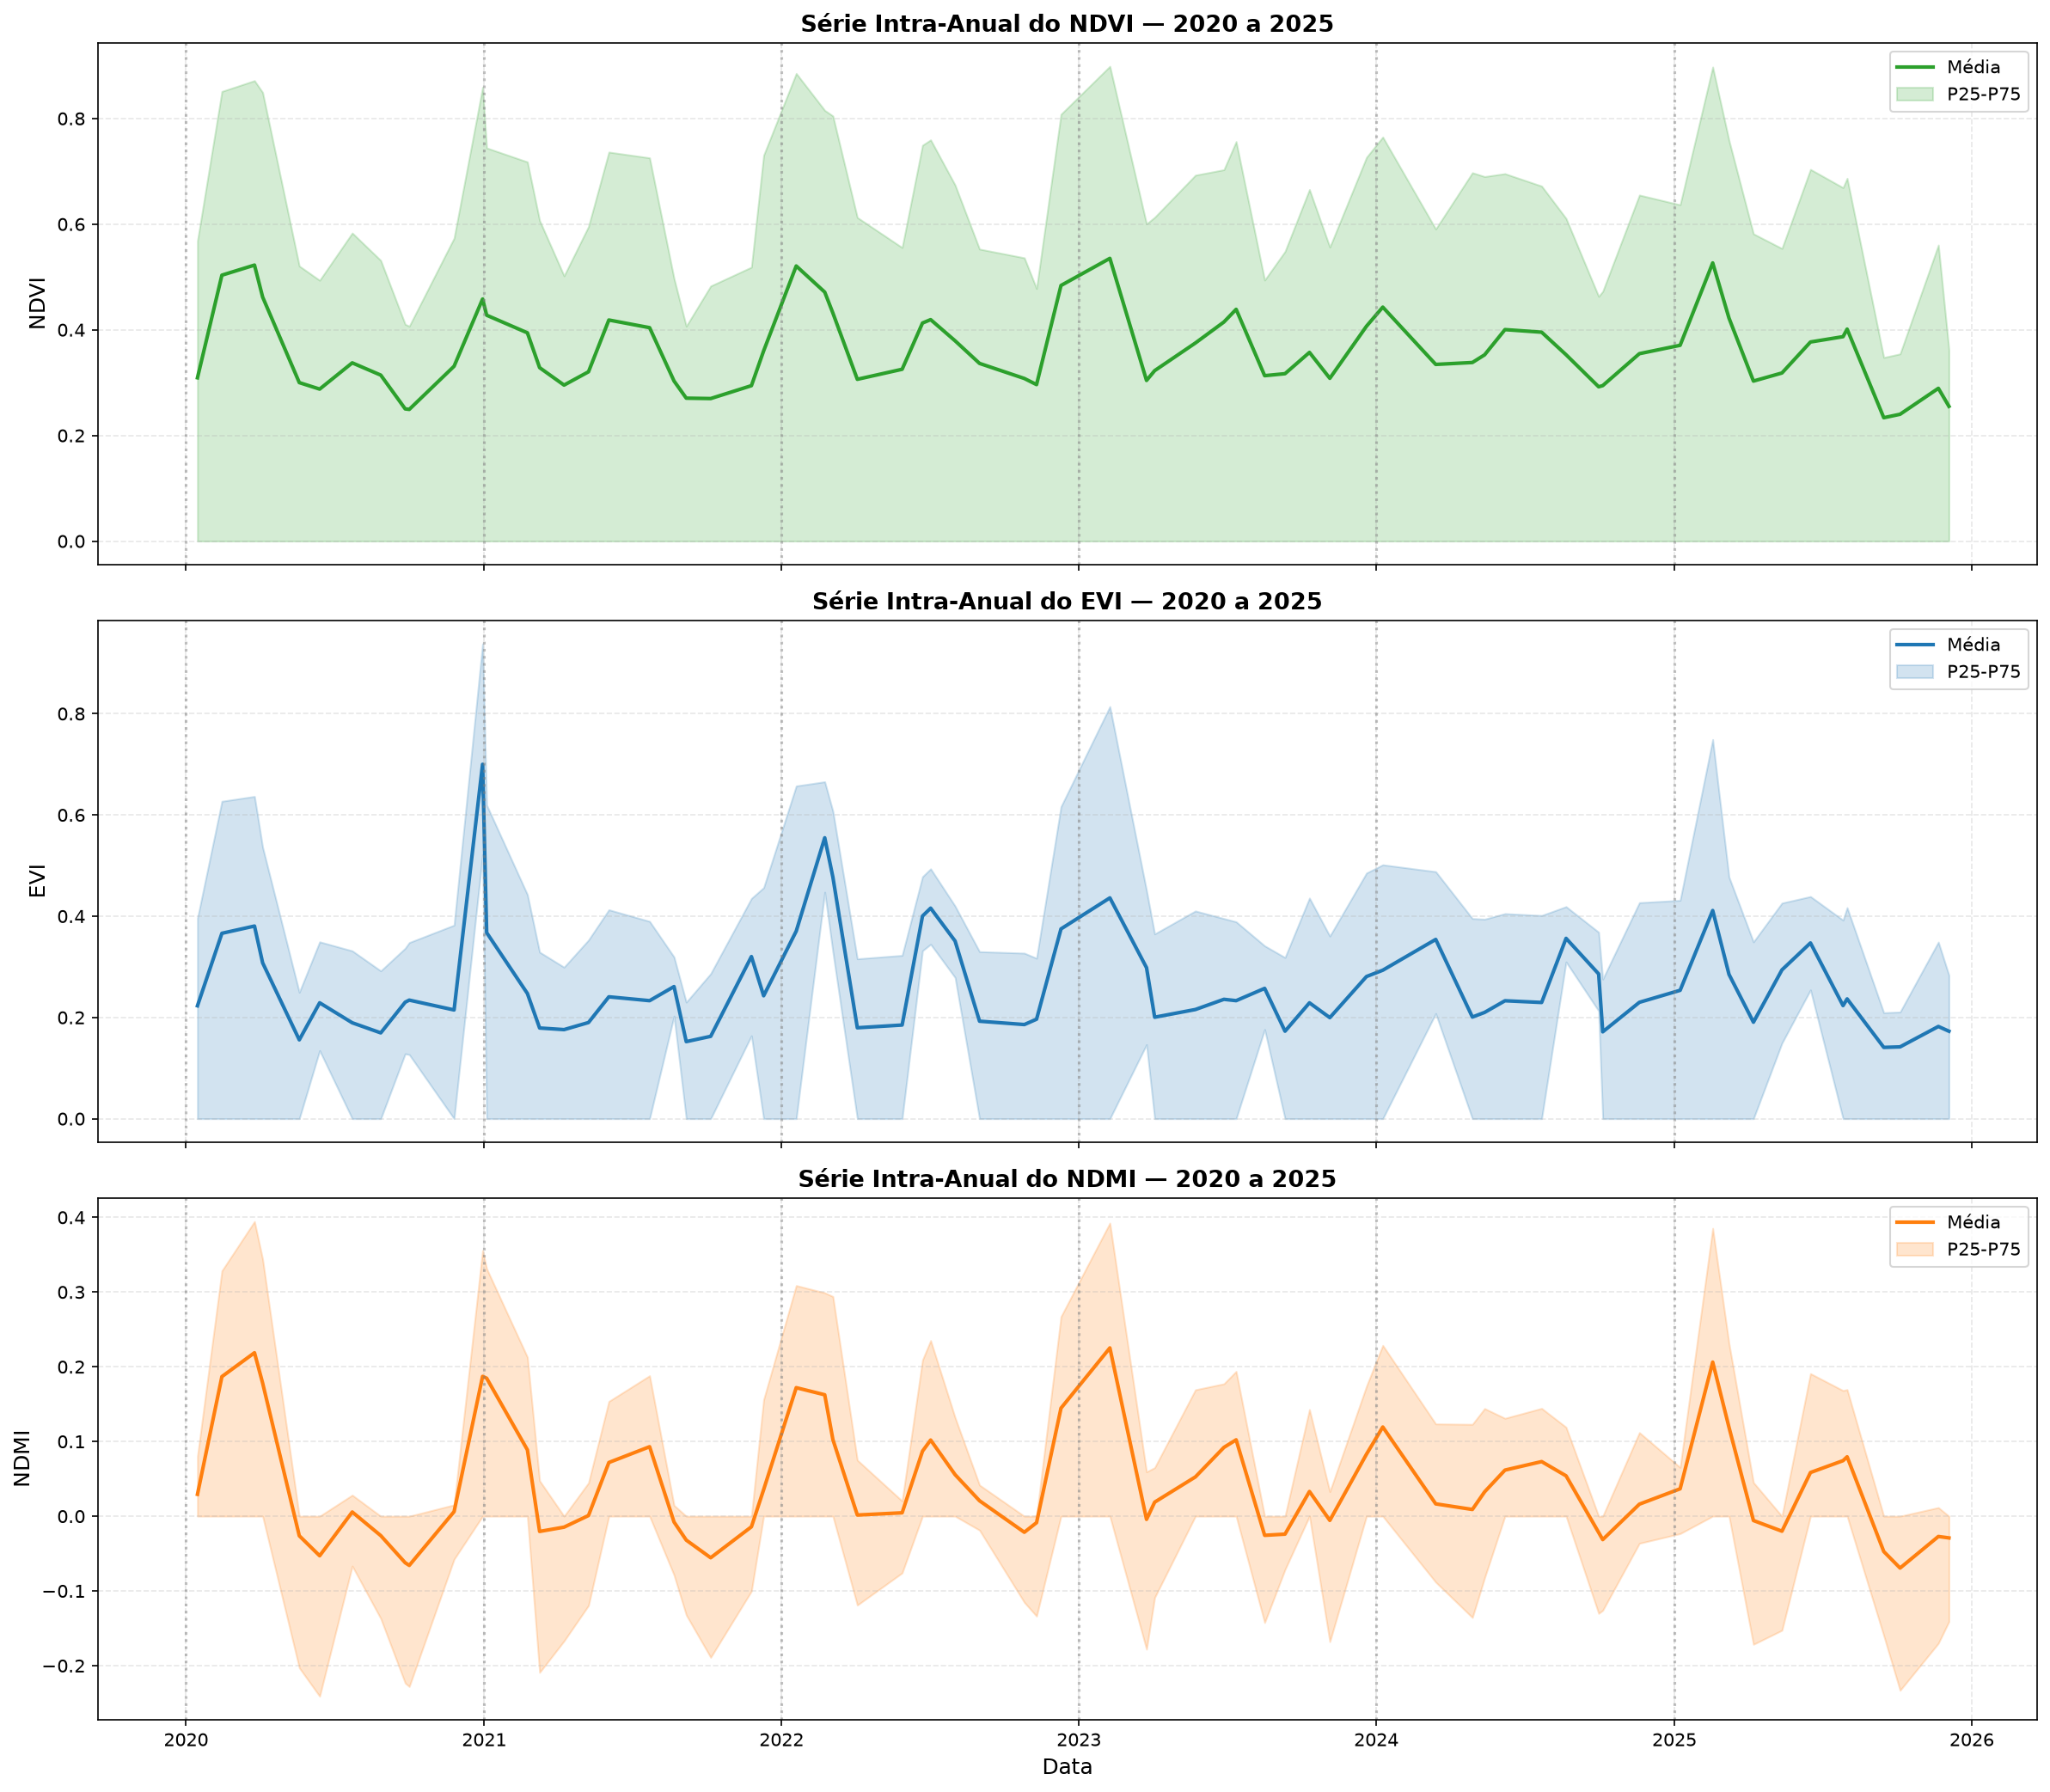

In [4]:
# ============================================================
# 3 - GRÁFICO — SÉRIE INTRA-ANUAL COMPLETA (2020-2025)
# ============================================================

fig, axes = plt.subplots(3, 1, figsize=(16, 14), dpi=150, sharex=True)

cores = {"NDVI": "#2ca02c", "EVI": "#1f77b4", "NDMI": "#ff7f0e"}

for ax, indice in zip(axes, ["NDVI", "EVI", "NDMI"]):
    sub = df_intraanual[df_intraanual["indice"] == indice].sort_values("data")
    
    ax.plot(sub["data"], sub["media"], '-', 
            color=cores[indice], linewidth=2, label="Média")
    
    ax.fill_between(sub["data"], sub["p25"], sub["p75"],
                     alpha=0.2, color=cores[indice], label="P25-P75")
    
    for ano in range(2020, 2026):
        ax.axvline(pd.Timestamp(f"{ano}-01-01"), 
                   color="gray", linestyle=":", alpha=0.5)
    
    ax.set_ylabel(indice, fontsize=12)
    ax.set_title(f"Série Intra-Anual do {indice} — 2020 a 2025",
                 fontsize=13, fontweight="bold")
    ax.grid(True, alpha=0.3, linestyle="--")
    ax.legend(loc="best", fontsize=10)

axes[-1].set_xlabel("Data", fontsize=12)
plt.tight_layout()

output = RESULTS_DIR / "serie_intraanual_completa.png"
plt.savefig(output, dpi=300, bbox_inches="tight")
print(f"✅ Gráfico salvo: {output}")

plt.show()

SAZONALIDADE — MÉDIA POR MÊS

📊 NDVI
 mes  media  mediana   std
   1  0.414    0.556 0.080
   2  0.486    0.766 0.057
   3  0.391    0.404 0.083
   4  0.338    0.237 0.063
   5  0.332    0.290 0.027
   6  0.385    0.508 0.050
   7  0.397    0.515 0.034
   8  0.344    0.405 0.040
   9  0.283    0.266 0.039
  10  0.286    0.230 0.043
  11  0.312    0.272 0.026
  12  0.393    0.495 0.091

📊 EVI
 mes  media  mediana   std
   1  0.302    0.386 0.066
   2  0.403    0.487 0.112
   3  0.329    0.333 0.101
   4  0.209    0.147 0.049
   5  0.208    0.181 0.047
   6  0.281    0.309 0.074
   7  0.254    0.280 0.081
   8  0.272    0.270 0.071
   9  0.196    0.165 0.054
  10  0.188    0.166 0.037
  11  0.224    0.190 0.050
  12  0.354    0.349 0.207

📊 NDMI
 mes  media  mediana   std
   1  0.108    0.085 0.073
   2  0.174    0.242 0.053
   3  0.072    0.000 0.092
   4  0.031    0.000 0.073
   5  0.007    0.000 0.030
   6  0.053    0.000 0.054
   7  0.075    0.003 0.036
   8  0.022    0.000 0.047
   

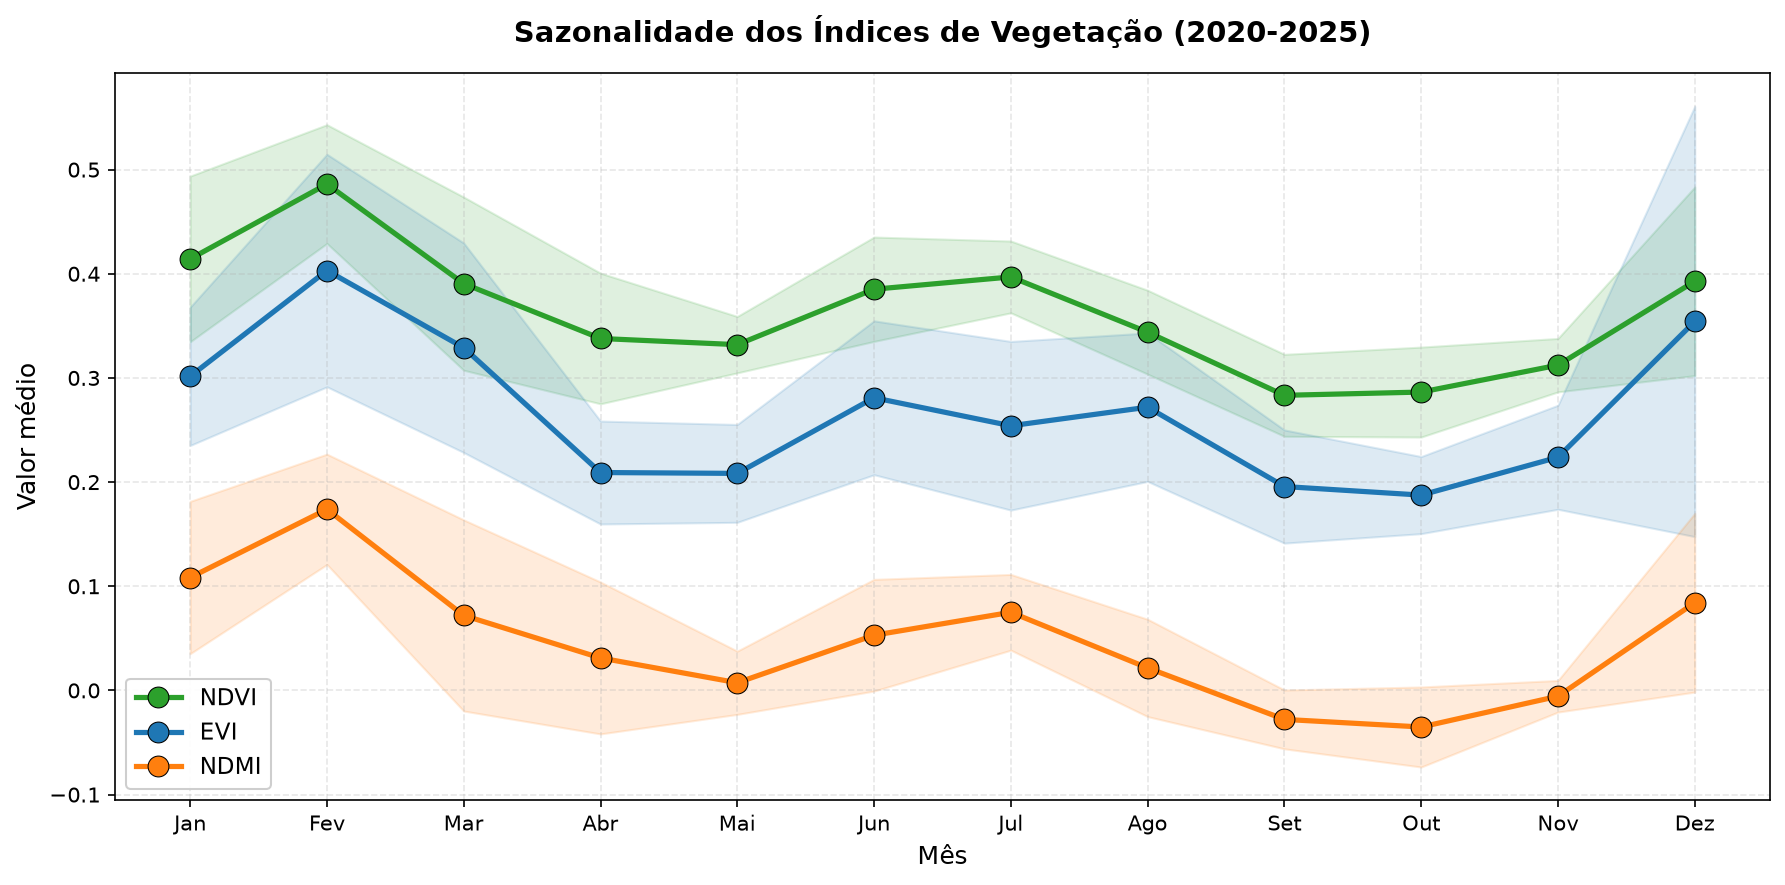

✅ Tabela salva: C:\Users\bbert_xwhb76k\analises-GIS\01-monitoramento-vegetacao\results\sazonalidade.csv


In [5]:
# ============================================================
# 4- SAZONALIDADE — MÉDIA POR MÊS (2020-2025)
# ============================================================

df_sazonalidade = df_intraanual.groupby(["indice", "mes"]).agg(
    media=("media", "mean"),
    mediana=("mediana", "median"),
    std=("media", "std")
).reset_index()

print("=" * 100)
print("SAZONALIDADE — MÉDIA POR MÊS")
print("=" * 100)

for indice in ["NDVI", "EVI", "NDMI"]:
    print(f"\n📊 {indice}")
    sub = df_sazonalidade[df_sazonalidade["indice"] == indice]
    print(sub[["mes", "media", "mediana", "std"]].to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 6), dpi=150)

meses = ["Jan", "Fev", "Mar", "Abr", "Mai", "Jun",
         "Jul", "Ago", "Set", "Out", "Nov", "Dez"]

for indice in ["NDVI", "EVI", "NDMI"]:
    sub = df_sazonalidade[df_sazonalidade["indice"] == indice].sort_values("mes")
    ax.plot(sub["mes"], sub["media"], 'o-',
            color=cores[indice], linewidth=2.5, markersize=10,
            label=indice, markeredgecolor="black", markeredgewidth=0.5)
    
    ax.fill_between(sub["mes"], 
                     sub["media"] - sub["std"], 
                     sub["media"] + sub["std"],
                     alpha=0.15, color=cores[indice])

ax.set_xlabel("Mês", fontsize=12)
ax.set_ylabel("Valor médio", fontsize=12)
ax.set_title("Sazonalidade dos Índices de Vegetação (2020-2025)",
             fontsize=14, fontweight="bold", pad=15)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(meses)
ax.grid(True, alpha=0.3, linestyle="--")
ax.legend(loc="best", fontsize=11, framealpha=0.95)

plt.tight_layout()

output = RESULTS_DIR / "sazonalidade.png"
plt.savefig(output, dpi=300, bbox_inches="tight")
print(f"\n✅ Gráfico salvo: {output}")

plt.show()

output = RESULTS_DIR / "sazonalidade.csv"
df_sazonalidade.to_csv(output, index=False)
print(f"✅ Tabela salva: {output}")

In [6]:
# ============================================================
# 5- ANOMALIAS INTRA-ANUAIS
# ============================================================

df_anomalia = df_intraanual.merge(
    df_sazonalidade[["indice", "mes", "media"]].rename(columns={"media": "media_sazonal"}),
    on=["indice", "mes"],
    how="left"
)

df_anomalia["anomalia"] = df_anomalia["media"] - df_anomalia["media_sazonal"]
df_anomalia["anomalia_pct"] = (df_anomalia["anomalia"] / df_anomalia["media_sazonal"]) * 100

def classificar_anomalia(row):
    if row["anomalia"] > 0.1:
        return "Muito acima"
    elif row["anomalia"] > 0.05:
        return "Acima"
    elif row["anomalia"] < -0.1:
        return "Muito abaixo"
    elif row["anomalia"] < -0.05:
        return "Abaixo"
    else:
        return "Normal"

df_anomalia["classificacao"] = df_anomalia.apply(classificar_anomalia, axis=1)

print("=" * 100)
print("ANOMALIAS INTRA-ANUAIS")
print("=" * 100)

print("\nDistribuição das anomalias por índice:")
print(pd.crosstab(df_anomalia["indice"], df_anomalia["classificacao"]))

print("\n📉 Top 10 anomalias NEGATIVAS:")
top_neg = df_anomalia.nsmallest(10, "anomalia")[
    ["indice", "data_str", "media", "media_sazonal", "anomalia", "classificacao"]
]
print(top_neg.to_string(index=False))

print("\n📈 Top 10 anomalias POSITIVAS:")
top_pos = df_anomalia.nlargest(10, "anomalia")[
    ["indice", "data_str", "media", "media_sazonal", "anomalia", "classificacao"]
]
print(top_pos.to_string(index=False))

output = RESULTS_DIR / "anomalias_intraanuais.csv"
df_anomalia.to_csv(output, index=False)
print(f"\n✅ Salvo: {output}")

ANOMALIAS INTRA-ANUAIS

Distribuição das anomalias por índice:
classificacao  Abaixo  Acima  Muito abaixo  Muito acima  Normal
indice                                                         
EVI                 6     10             5            5      43
NDMI                7      6             2            3      51
NDVI                6      5             2            3      53

📉 Top 10 anomalias NEGATIVAS:
indice data_str  media  media_sazonal  anomalia classificacao
   EVI 20251204  0.173          0.354    -0.181  Muito abaixo
   EVI 20210223  0.247          0.403    -0.156  Muito abaixo
   EVI 20210310  0.179          0.329    -0.150  Muito abaixo
  NDVI 20251204  0.255          0.393    -0.138  Muito abaixo
  NDMI 20251204 -0.029          0.084    -0.113  Muito abaixo
   EVI 20211210  0.243          0.354    -0.111  Muito abaixo
  NDMI 20200613 -0.053          0.053    -0.106  Muito abaixo
  NDVI 20200115  0.309          0.414    -0.105  Muito abaixo
   EVI 20200827  0.170      

✅ Gráfico salvo: C:\Users\bbert_xwhb76k\analises-GIS\01-monitoramento-vegetacao\results\anomalias_intraanuais.png


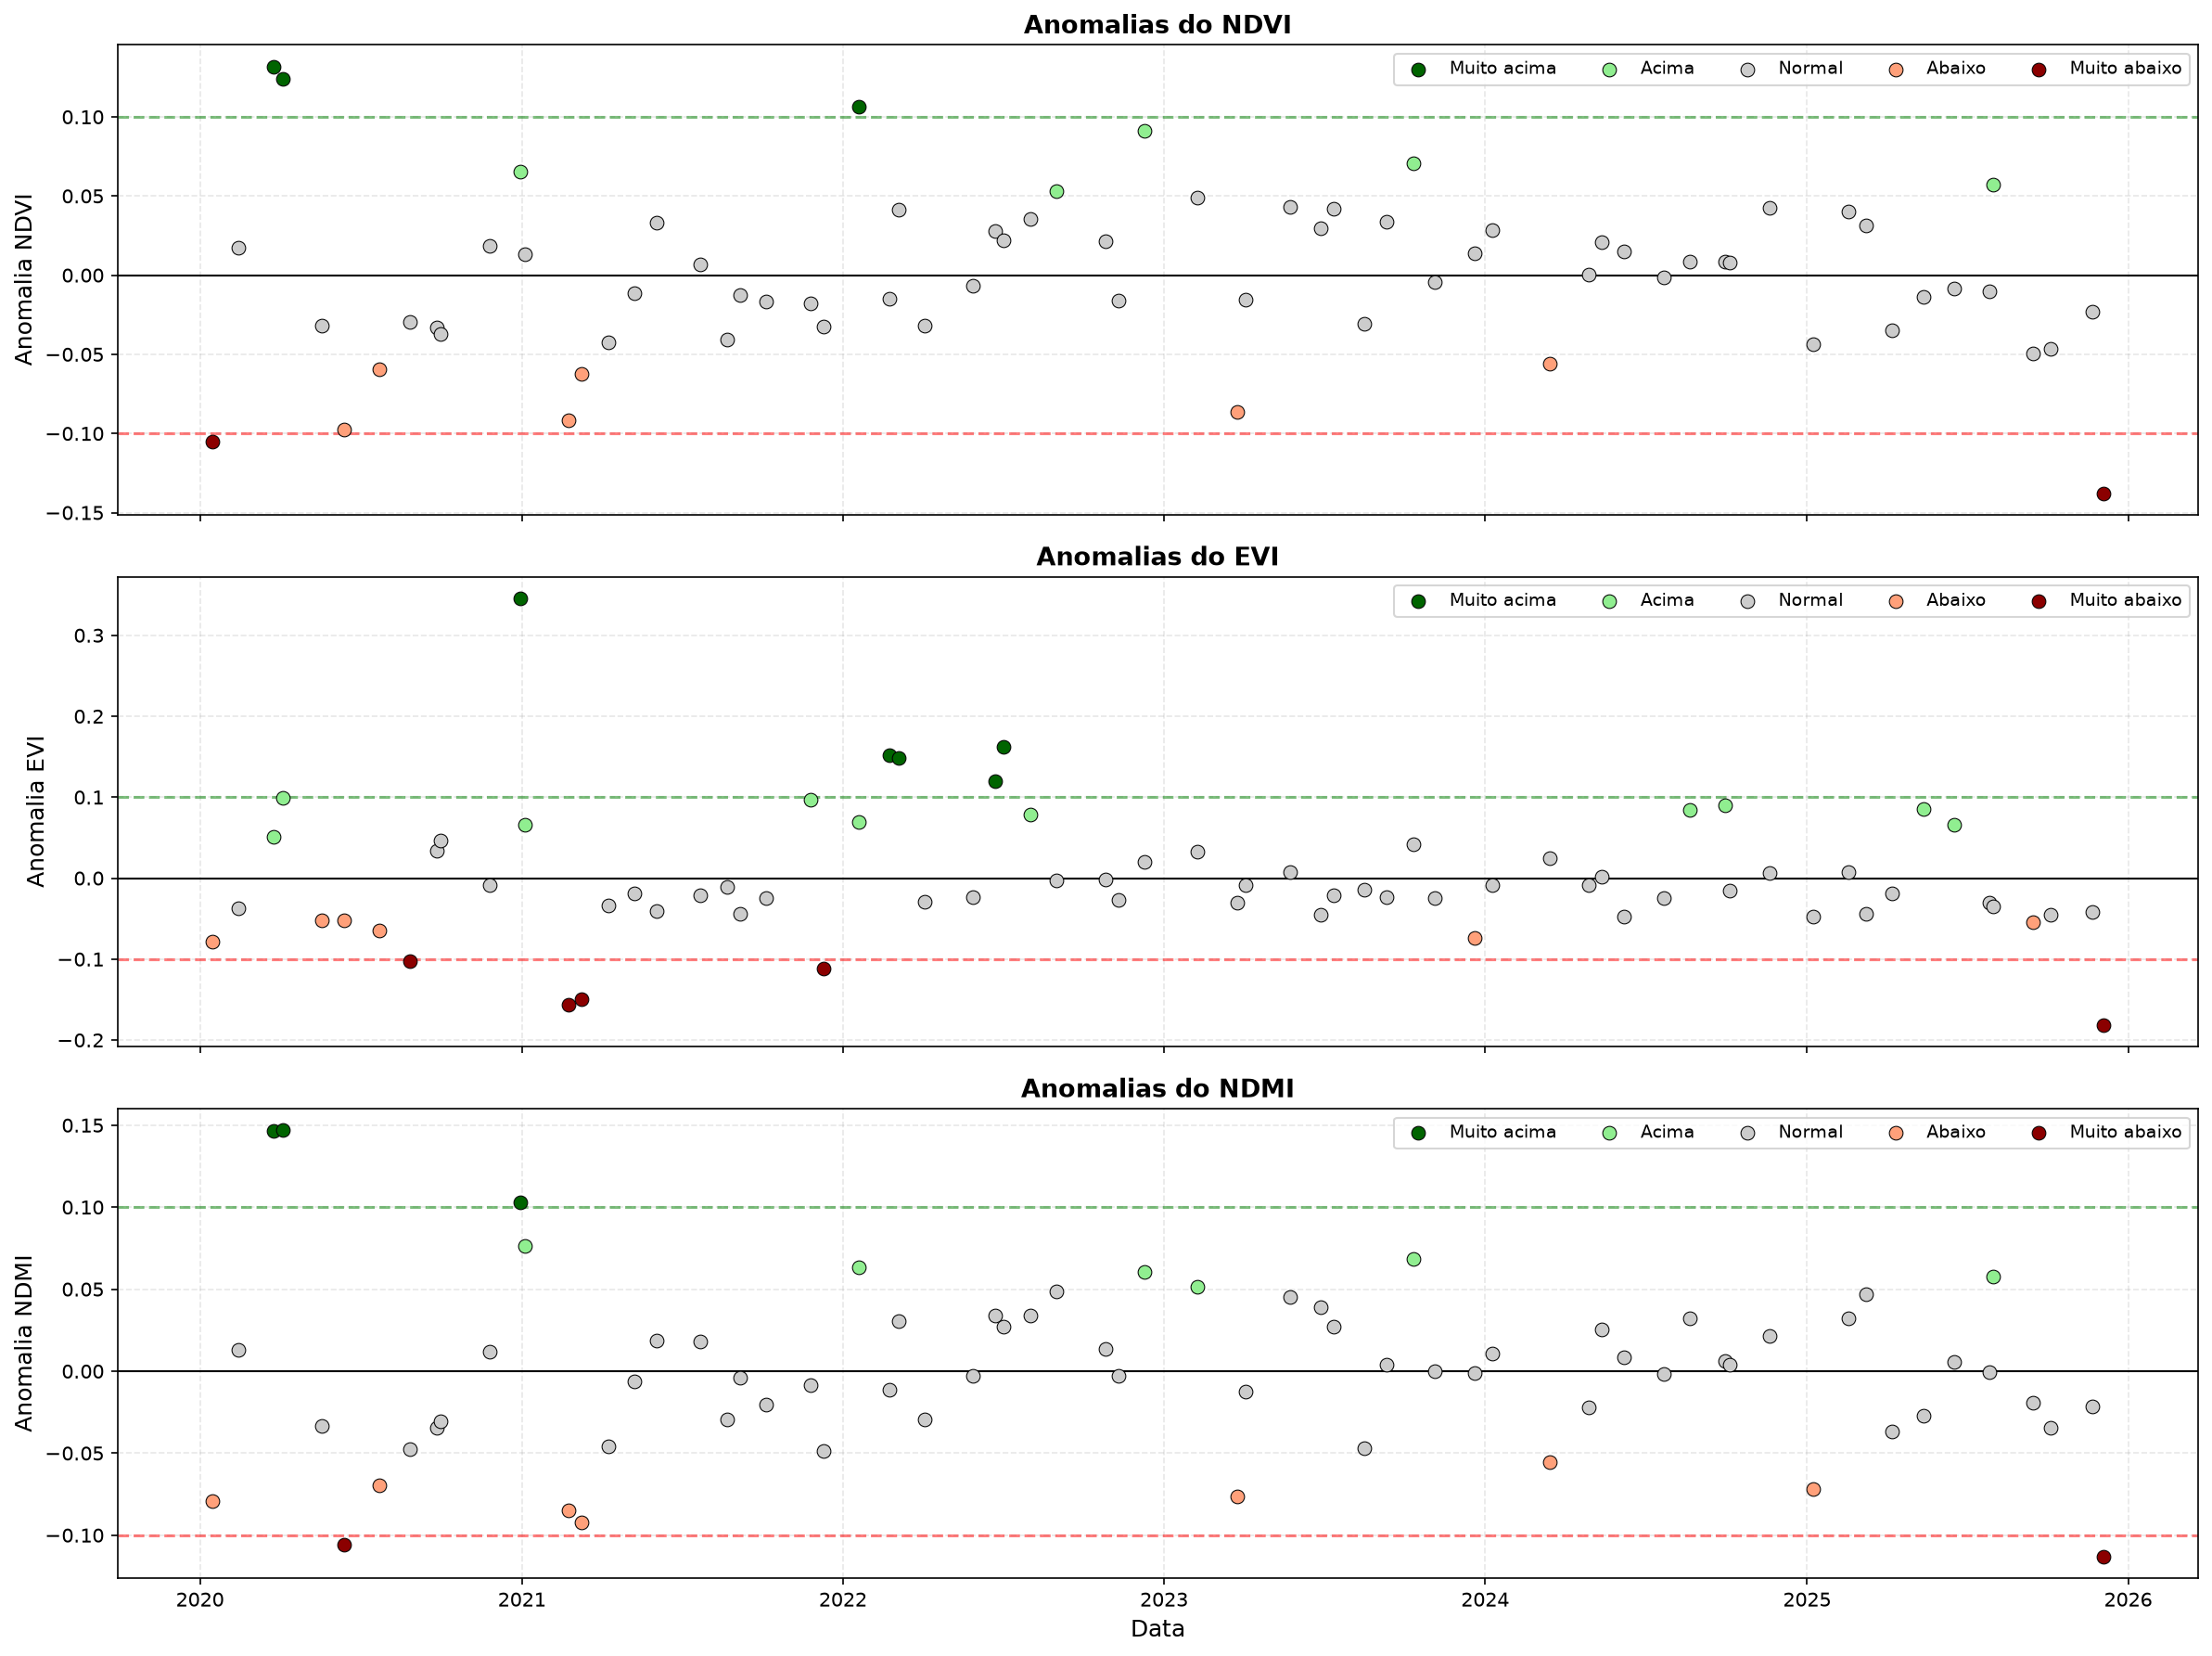

In [7]:
# ============================================================
# 6- GRÁFICO — ANOMALIAS INTRA-ANUAIS
# ============================================================

fig, axes = plt.subplots(3, 1, figsize=(16, 12), dpi=150, sharex=True)

cores_anom = {
    "Muito acima": "#006400",
    "Acima": "#90EE90",
    "Normal": "#CCCCCC",
    "Abaixo": "#FFA07A",
    "Muito abaixo": "#8B0000"
}

for ax, indice in zip(axes, ["NDVI", "EVI", "NDMI"]):
    sub = df_anomalia[df_anomalia["indice"] == indice].sort_values("data")
    
    for classe, cor in cores_anom.items():
        mask = sub["classificacao"] == classe
        if mask.sum() > 0:
            ax.scatter(sub.loc[mask, "data"], sub.loc[mask, "anomalia"],
                       c=cor, s=50, edgecolor="black", linewidth=0.5,
                       label=classe, zorder=3)
    
    ax.axhline(0, color="black", linewidth=1)
    ax.axhline(0.1, color="green", linestyle="--", alpha=0.5)
    ax.axhline(-0.1, color="red", linestyle="--", alpha=0.5)
    
    ax.set_ylabel(f"Anomalia {indice}", fontsize=12)
    ax.set_title(f"Anomalias do {indice}", fontsize=13, fontweight="bold")
    ax.grid(True, alpha=0.3, linestyle="--")
    ax.legend(loc="upper right", fontsize=9, ncol=5)

axes[-1].set_xlabel("Data", fontsize=12)
plt.tight_layout()

output = RESULTS_DIR / "anomalias_intraanuais.png"
plt.savefig(output, dpi=300, bbox_inches="tight")
print(f"✅ Gráfico salvo: {output}")

plt.show()